   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.4/198.4 kB 7.7 MB/s eta 0:00:00
Mounted at /content/drive
Last working day: 2025-04-30
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


First rows of stock data:
Price        Date       Close        High         Low        Open      Volume
Ticker            RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
0      1996-01-01    6.156049    6.166521    6.093218    6.133610   104121369
1      1996-01-02    6.108178    6.171010    6.063298    6.141090   168743308
2      1996-01-03    6.154554    6.491154    6.141090    6.208409   209323879
3      1996-01-04    6.097705    6.115657    6.015425    6.096209   216900264
4      1996-01-05    6.055817    6.073769    6.003457    6.073769   166708467


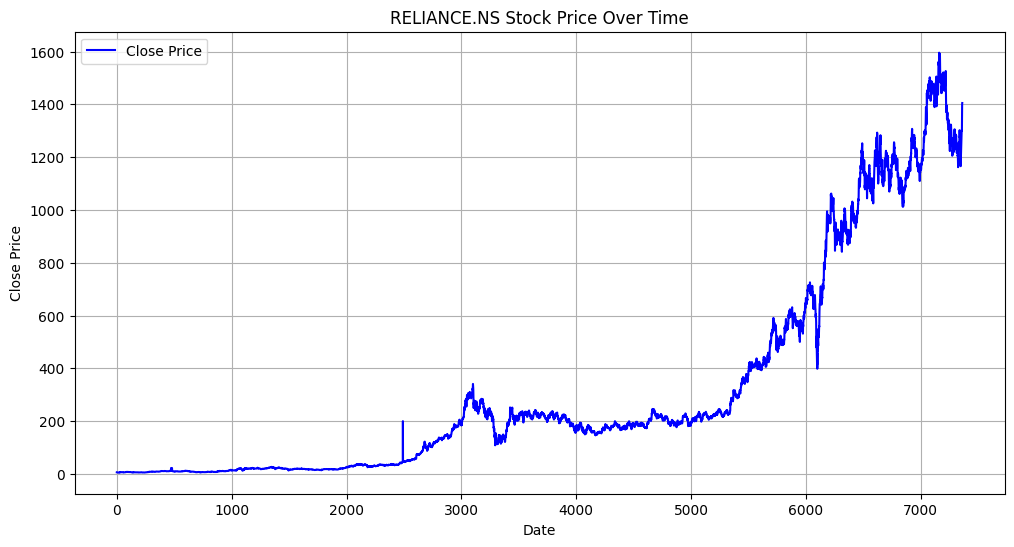

In [ ]:
!pip install yfinance --quiet
!pip install pandas_market_calendars --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import datetime
import numpy as np
import pandas_market_calendars as mcal
import warnings
warnings.filterwarnings('ignore')
drive.mount('/content/drive')

ticker = 'RELIANCE.NS'  # choose the Reliance stock as it is Stable .
stock = yf.Ticker(ticker)
nse = mcal.get_calendar('NSE')


today = datetime.datetime.today() #include real time calendar to ensure precission by examine holidays and weekends

# If today is Monday (0), we need Friday's date (today - 3 days)
# If today is Sunday (6), we need Friday's date (today - 2 days)
# If today is Saturday (5), we need Friday's date (today - 1 day)
# Otherwise (Tuesday to Friday), just take yesterday

start = today - datetime.timedelta(days=10)
end = today

schedule = nse.schedule(start_date=start.strftime('%Y-%m-%d'), end_date=end.strftime('%Y-%m-%d'))
trading_days = schedule.index

if today.date() in trading_days.date:
    last_working_day = today.date()
else:
    last_working_day = trading_days[trading_days < np.datetime64(today)].max().date()

print(f"Last working day: {last_working_day}")

# Here we Download data up to the LAST working day.
df = yf.download(ticker, end=(last_working_day + datetime.timedelta(days=1)).strftime('%Y-%m-%d'))
df.reset_index(inplace=True)

save_path = "/content/drive/My Drive/DS_Dataset_FinanceTrends.csv"
df.to_csv(save_path, index=True)

df_copy=df.copy()

print("First rows of stock data:")
print(df.head())


plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.title(f"{ticker} Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df.isnull().sum()
# Here we want to know is there any missing value ?

,,0
Price,Ticker,
Date,,0
Close,RELIANCE.NS,0
High,RELIANCE.NS,0
Low,RELIANCE.NS,0
Open,RELIANCE.NS,0
Volume,RELIANCE.NS,0


In [ ]:
df.tail()

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
7357,2025-04-24,1301.599976,1304.500000,1290.300049,1292.400024,10468940
7358,2025-04-25,1300.400024,1325.199951,1288.099976,1303.500000,14431012
7359,2025-04-28,1368.800049,1374.599976,1320.199951,1340.000000,31104496
7360,2025-04-29,1399.699951,1410.900024,1370.000000,1371.000000,32538970
7361,2025-04-30,1405.000000,1412.400024,1369.000000,1402.000000,25478243


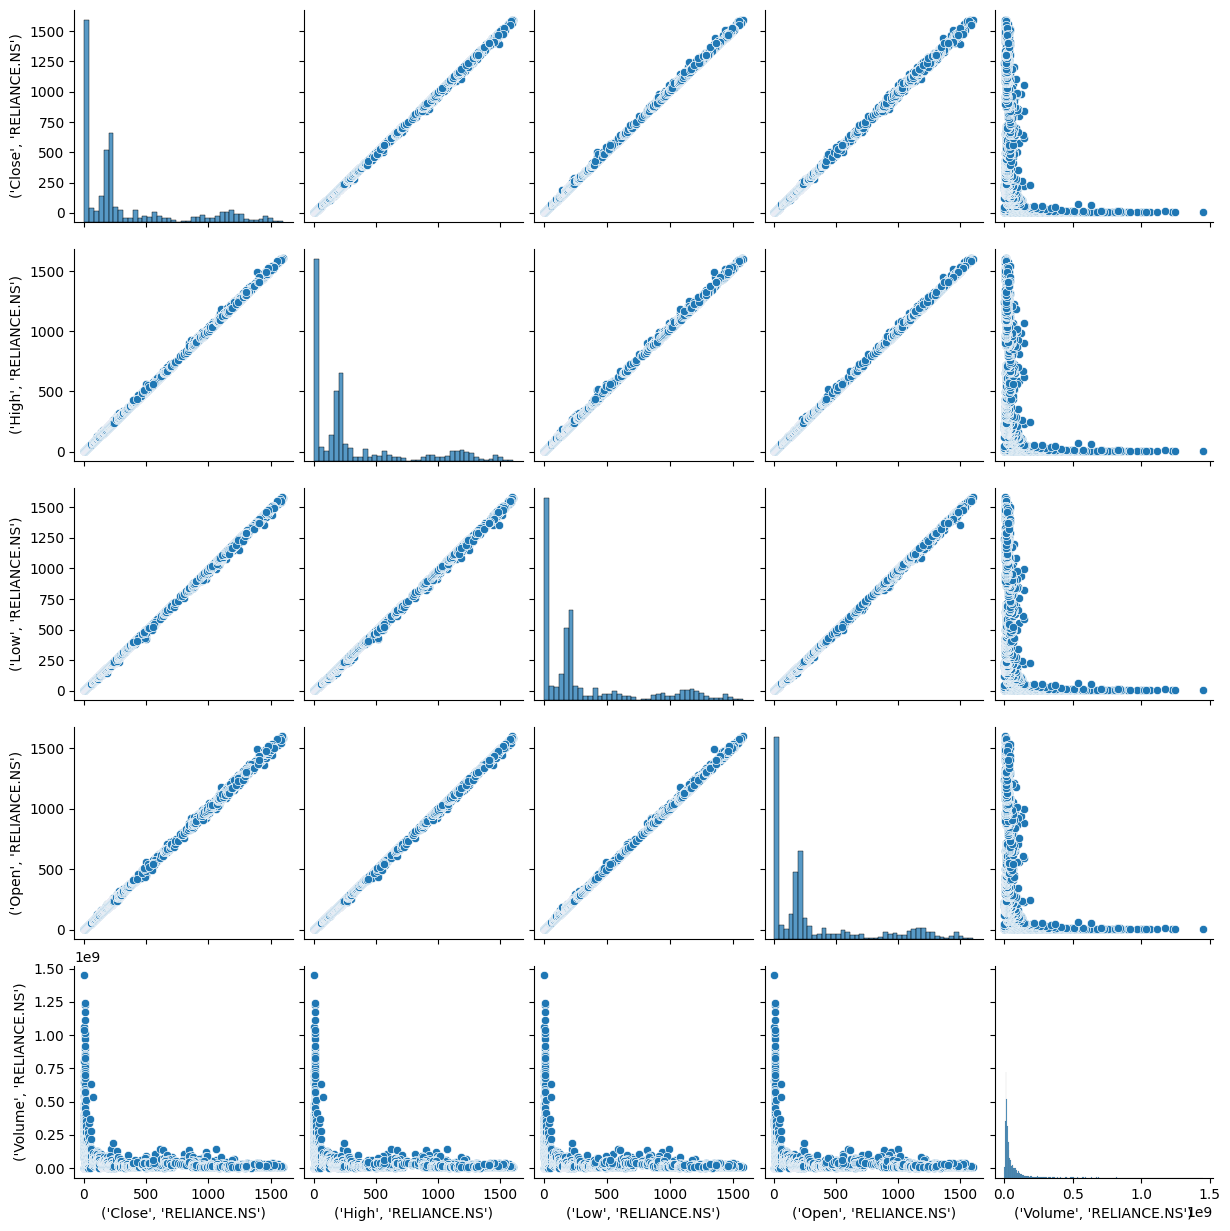

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)

In [ ]:
df.drop(columns=['Dividends', 'Stock Splits'], inplace=True, errors='ignore') #Removing constant columns
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,1996-01-01,6.156049,6.166521,6.093218,6.133610,104121369
1,1996-01-02,6.108178,6.171010,6.063298,6.141090,168743308
2,1996-01-03,6.154554,6.491154,6.141090,6.208409,209323879
3,1996-01-04,6.097705,6.115657,6.015425,6.096209,216900264
4,1996-01-05,6.055817,6.073769,6.003457,6.073769,166708467


In [ ]:
import numpy as np

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

# Introduce lag ,Close,Rolling Means
df['lag_1'] = df['Close'].shift(1)
df['lag_5'] = df['Close'].shift(5)
df['lag_10'] = df['Close'].shift(10)

df['rolling_mean_5'] = df['Close'].rolling(window=5).mean()
df['rolling_mean_10'] = df['Close'].rolling(window=10).mean()
df['rolling_mean_20'] = df['Close'].rolling(window=20).mean()

df['Daily_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

df['Log_Volume'] = df['Volume'].shift(1)
df['Rolling_Volume'] = df['Volume'].rolling(3).mean()

df.dropna(inplace=True)

In [ ]:
df_raw=df.copy()
df.drop(columns=['Date'], inplace=True, errors='ignore')  #removing categorical columns, doesnt has any significant affect on data no point of encoding it
df.head()

Price,Close,High,Low,Open,Volume,Year,Month,Day,DayOfWeek,IsMonthStart,...,lag_1,lag_5,lag_10,rolling_mean_5,rolling_mean_10,rolling_mean_20,Daily_Return,Log_Return,Log_Volume,Rolling_Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,,,...,,,,,,,,,,
19,4.598711,4.598711,4.598711,4.598711,0,1996,1,26,4,0,...,4.598711,5.104360,5.613001,4.832088,5.092392,5.487112,0.000000,0.000000,3.608558e+08,2.373472e+08
20,4.960743,5.004128,4.549344,4.577767,652902286,1996,1,29,0,0,...,4.598711,5.191129,5.554657,4.786011,5.033001,5.427347,0.078725,0.075779,0.000000e+00,3.379194e+08
21,5.406552,5.654889,5.041528,5.116327,1061936020,1996,1,30,1,0,...,4.960743,4.971216,5.565128,4.873078,5.017143,5.392266,0.089867,0.086056,6.529023e+08,5.716128e+08
22,5.288369,5.557649,5.153728,5.355689,731560842,1996,1,31,2,0,...,5.406552,4.800672,5.343720,4.970617,5.011608,5.348956,-0.021859,-0.022102,1.061936e+09,8.154664e+08
23,5.500800,5.535208,5.221048,5.236007,640422958,1996,2,1,3,1,...,5.288369,4.598711,5.195616,5.151035,5.042126,5.319111,0.040169,0.039384,7.315608e+08,8.113066e+08


In [ ]:
df.head(8)

Price,Close,High,Low,Open,Volume,Year,Month,Day,DayOfWeek,IsMonthStart,...,lag_1,lag_5,lag_10,rolling_mean_5,rolling_mean_10,rolling_mean_20,Daily_Return,Log_Return,Log_Volume,Rolling_Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,,,...,,,,,,,,,,
19,4.598711,4.598711,4.598711,4.598711,0,1996,1,26,4,0,...,4.598711,5.104360,5.613001,4.832088,5.092392,5.487112,0.000000,0.000000,3.608558e+08,2.373472e+08
20,4.960743,5.004128,4.549344,4.577767,652902286,1996,1,29,0,0,...,4.598711,5.191129,5.554657,4.786011,5.033001,5.427347,0.078725,0.075779,0.000000e+00,3.379194e+08
21,5.406552,5.654889,5.041528,5.116327,1061936020,1996,1,30,1,0,...,4.960743,4.971216,5.565128,4.873078,5.017143,5.392266,0.089867,0.086056,6.529023e+08,5.716128e+08
22,5.288369,5.557649,5.153728,5.355689,731560842,1996,1,31,2,0,...,5.406552,4.800672,5.343720,4.970617,5.011608,5.348956,-0.021859,-0.022102,1.061936e+09,8.154664e+08
23,5.500800,5.535208,5.221048,5.236007,640422958,1996,2,1,3,1,...,5.288369,4.598711,5.195616,5.151035,5.042126,5.319111,0.040169,0.039384,7.315608e+08,8.113066e+08
24,6.097705,6.163529,5.647408,5.647408,818725675,1996,2,2,4,0,...,5.500800,4.598711,5.104360,5.450834,5.141461,5.321205,0.108512,0.103019,6.404230e+08,7.302365e+08
25,6.604850,6.737994,6.239826,6.432810,1222482548,1996,2,5,0,0,...,6.097705,4.960743,5.191129,5.779655,5.282833,5.360775,0.083170,0.079892,8.187257e+08,8.938771e+08
26,6.051329,6.881611,5.912201,6.763427,1242315590,1996,2,6,1,0,...,6.604850,5.406552,4.971216,5.908611,5.390844,5.381045,-0.083805,-0.087526,1.222483e+09,1.094508e+09


<Axes: xlabel='Price-Ticker', ylabel='Price-Ticker'>

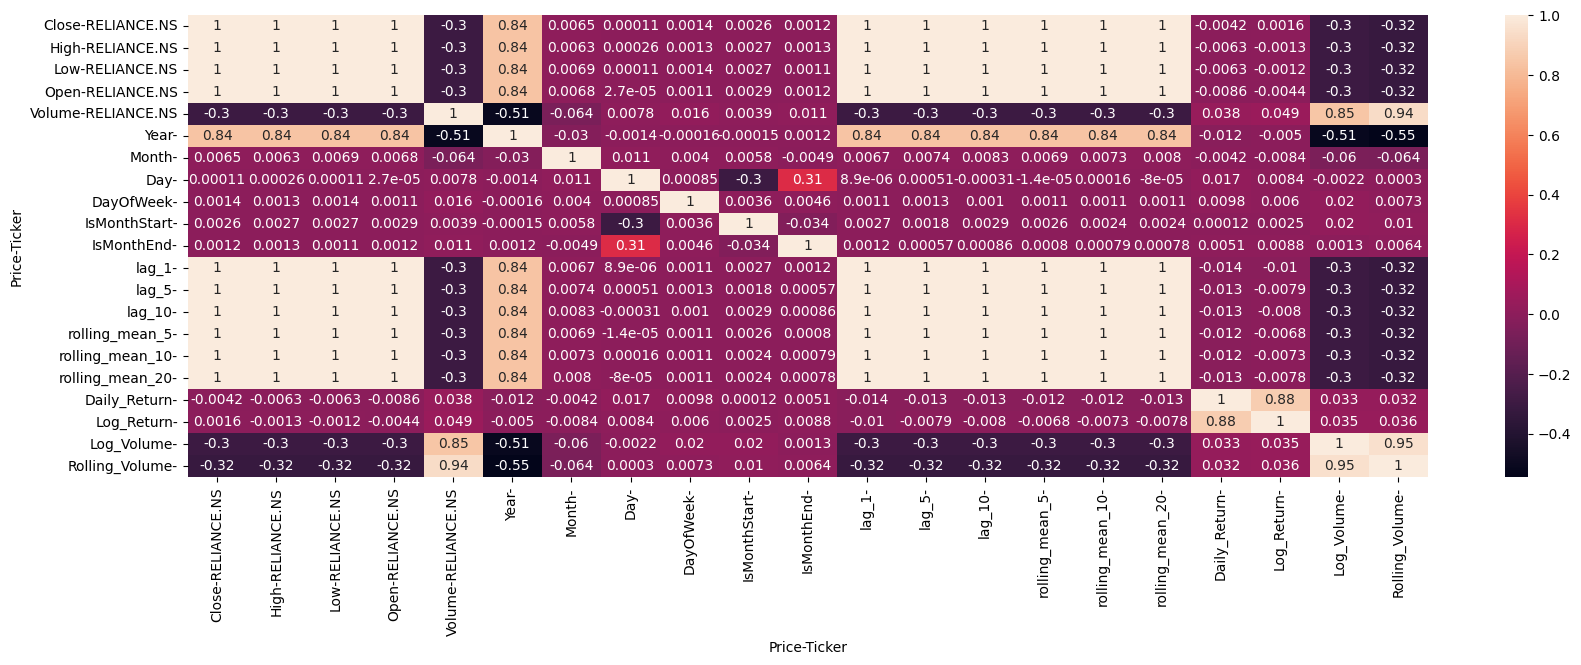

In [ ]:
plt.figure(figsize=(20, 6))
sns.heatmap(data=df.corr(),annot=True) #using heatmap for correlation analysis.

In [ ]:
 #we are dropping the columns which are higly correlated to avoid overfitting
df.drop(columns=['lag_5','lag_10','Open','Low','Rolling_Volume','Daily_Return','IsMonthStart','rolling_mean_10','rolling_mean_20'], inplace=True, errors='ignore')
df.head()

Price,Close,High,Volume,Year,Month,Day,DayOfWeek,IsMonthEnd,lag_1,rolling_mean_5,Log_Return,Log_Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,,,,,,
19,4.598711,4.598711,0,1996,1,26,4,0,4.598711,4.832088,0.000000,3.608558e+08
20,4.960743,5.004128,652902286,1996,1,29,0,0,4.598711,4.786011,0.075779,0.000000e+00
21,5.406552,5.654889,1061936020,1996,1,30,1,0,4.960743,4.873078,0.086056,6.529023e+08
22,5.288369,5.557649,731560842,1996,1,31,2,1,5.406552,4.970617,-0.022102,1.061936e+09
23,5.500800,5.535208,640422958,1996,2,1,3,0,5.288369,5.151035,0.039384,7.315608e+08


<Axes: xlabel='Price-Ticker', ylabel='Price-Ticker'>

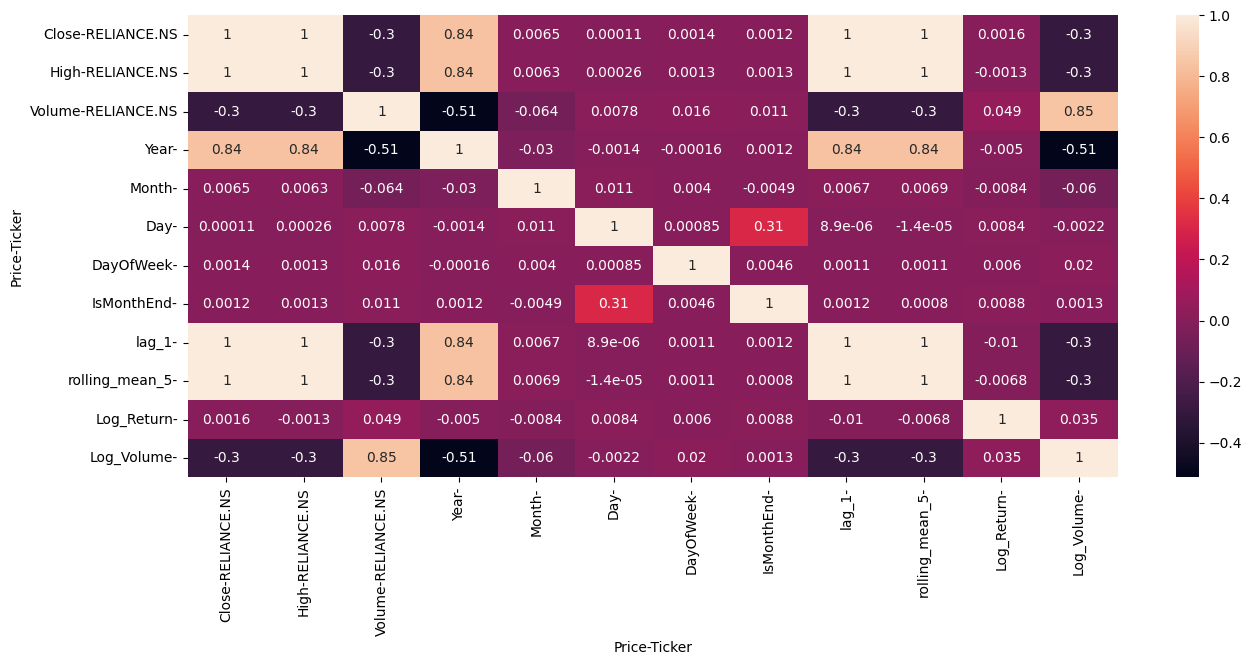

In [ ]:
plt.figure(figsize=(15, 6))
sns.heatmap(data=df.corr(),annot=True)

In [ ]:
today_data=df_raw.iloc[-1]
df=df.iloc[:-1]
df.describe()

Price,Close,High,Volume,Year,Month,Day,DayOfWeek,IsMonthEnd,lag_1,rolling_mean_5,Log_Return,Log_Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,,,,,,
count,7342.000000,7342.000000,7.342000e+03,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7.342000e+03
mean,324.542695,328.377129,5.858940e+07,2010.022337,6.488423,15.767230,1.997412,0.033506,324.352678,324.173322,0.000779,5.863412e+07
std,406.132379,410.168949,1.012540e+08,8.488013,3.447280,8.788043,1.413681,0.179966,405.955602,405.732403,0.034524,1.013150e+08
min,4.598711,4.598711,0.000000e+00,1996.000000,1.000000,1.000000,0.000000,0.000000,4.598711,4.786011,-1.469437,0.000000e+00
25%,21.865529,22.258380,1.359040e+07,2003.000000,3.000000,8.000000,1.000000,0.000000,21.813802,21.766508,-0.010594,1.359040e+07
50%,186.945045,189.512929,2.397078e+07,2010.000000,6.000000,16.000000,2.000000,0.000000,186.923851,186.895981,0.000264,2.397078e+07
75%,401.212166,405.328986,6.129206e+07,2017.000000,9.000000,23.000000,3.000000,0.000000,400.978523,401.469183,0.011449,6.129899e+07
max,1595.484985,1603.358288,1.448889e+09,2025.000000,12.000000,31.000000,6.000000,1.000000,1595.484985,1585.174951,1.475855,1.448889e+09


In [ ]:
df=df[['High', 'Close', 'Volume', 'lag_1', 'rolling_mean_5', 'Log_Return']]

In [ ]:
df["Close"].describe()

Ticker,RELIANCE.NS
count,7342.000000
mean,324.542695
std,406.132379
min,4.598711
25%,21.865529
50%,186.945045
75%,401.212166
max,1595.484985


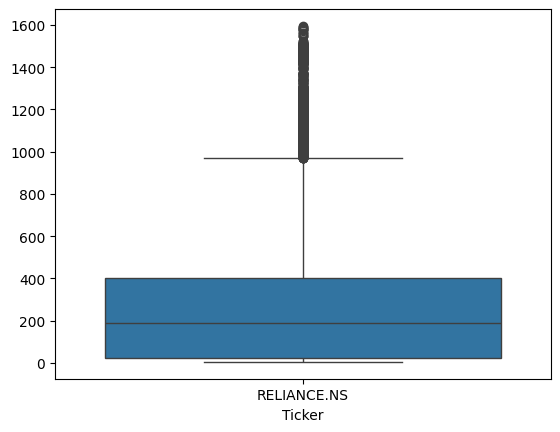

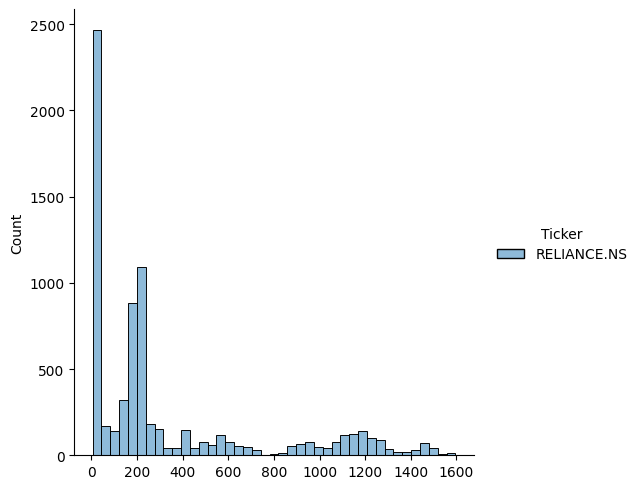

In [ ]:
sns.boxplot(df['Close'])    #Checking for outliers, because for stock market outliers indicate trend breakers
sns.displot(df['Close'])
plt.show()

In [ ]:
df.head()

Price,High,Close,Volume,lag_1,rolling_mean_5,Log_Return
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,
19,4.598711,4.598711,0,4.598711,4.832088,0.000000
20,5.004128,4.960743,652902286,4.598711,4.786011,0.075779
21,5.654889,5.406552,1061936020,4.960743,4.873078,0.086056
22,5.557649,5.288369,731560842,5.406552,4.970617,-0.022102
23,5.535208,5.500800,640422958,5.288369,5.151035,0.039384


In [ ]:
import warnings
warnings.filterwarnings('ignore')
today_data_df = pd.DataFrame([today_data])
today_data_df=today_data_df[['High', 'Close', 'Volume', 'lag_1', 'rolling_mean_5', 'Log_Return']]
# today_data_df.drop(columns=['Date','lag_5','lag_10','Open','Low','Rolling_Volume','Daily_Return','IsMonthStart','rolling_mean_10','rolling_mean_20'], inplace=True, errors='ignore')
today_data_df.head()
close=today_data_df['Close']
print(close)

Ticker  RELIANCE.NS
7361         1405.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

X = df.drop(['Close'], axis=1)
y = df['Close']

# Sort the data by date
df = df.sort_index()

#split data into train and test data (80 % training data & 20 % test data)
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Use some Well known Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    }

results_df = pd.DataFrame(results).T
print(results_df)

                          MAE        RMSE  R² Score
Linear Regression    7.885069   10.424668  0.998457
Ridge Regression     8.179425   10.910293  0.998310
Lasso Regression     7.840586   10.016226  0.998576
Random Forest      444.586796  511.242135 -2.710060
Decision Tree      442.818038  509.503439 -2.684868
Gradient Boosting  446.107673  512.714562 -2.731462
XGBoost            451.769104  517.869826 -2.806878


Best Model Selected: Lasso Regression


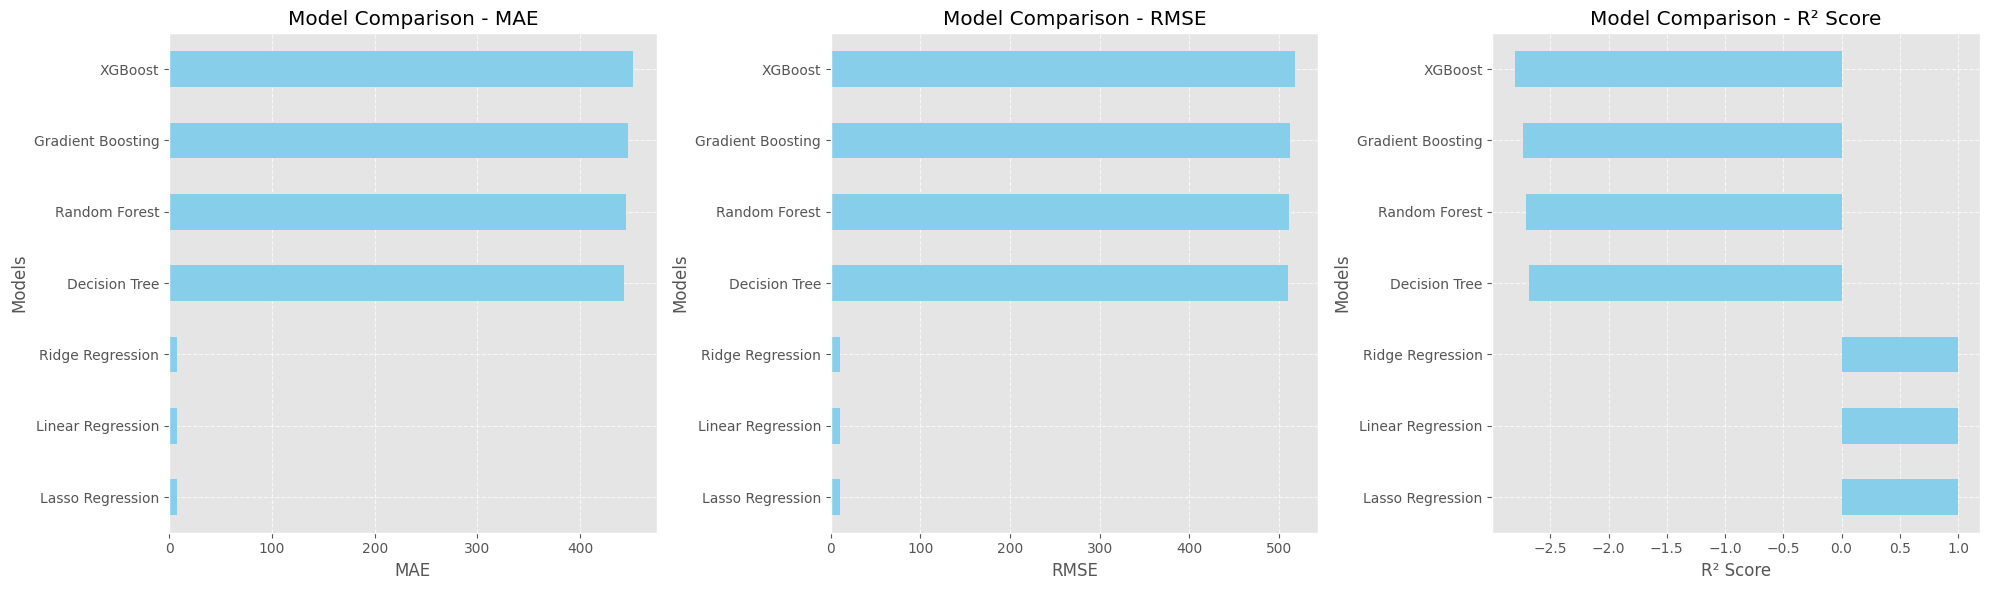

In [ ]:
best_model_name = results_df['R² Score'].idxmax()
best_model = models[best_model_name]

print(f"Best Model Selected: {best_model_name}")  # After Analysis we choose the best fit model for the project

import matplotlib.pyplot as plt

plt.style.use('ggplot')

metrics = ['MAE', 'RMSE', 'R² Score']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # Width=20, Height=6

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    sorted_data = results_df[metric].sort_values(ascending=True if metric != 'R² Score' else False)
    sorted_data.plot(kind='barh', ax=ax, color='skyblue')
    ax.set_title(f'Model Comparison - {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Models')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df.head()

Price,High,Close,Volume,lag_1,rolling_mean_5,Log_Return
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,
19,4.598711,4.598711,0,4.598711,4.832088,0.000000
20,5.004128,4.960743,652902286,4.598711,4.786011,0.075779
21,5.654889,5.406552,1061936020,4.960743,4.873078,0.086056
22,5.557649,5.288369,731560842,5.406552,4.970617,-0.022102
23,5.535208,5.500800,640422958,5.288369,5.151035,0.039384


In [ ]:
today_data_df.head()

Price,High,Close,Volume,lag_1,rolling_mean_5,Log_Return
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,
7361,1412.400024,1405.0,25478243,1399.699951,1355.1,0.003779


In [ ]:
today_data_df.fillna(0, inplace=True)
#X=df.drop(['Close'], axis=1)

today_data_df = today_data_df[['High', 'Volume', 'lag_1', 'rolling_mean_5', 'Log_Return']]
today_data_scaled = scaler.transform(today_data_df)

# Predict today's close
today_prediction = best_model.predict(today_data_scaled)
predicted_close = today_prediction.flatten()[0]

# Get actual close
actual_close = today_data['Close'].item()

# Calculate accuracy for todays Close
accuracy = (1 - abs(actual_close - predicted_close) / actual_close) * 100 #use R-square as it our best fit model

print("Today's Close Prediction Results")
print(f"Predicted Close Value ({best_model_name}): {predicted_close:.2f}")
print(f"Actual Close Value: {actual_close:.2f}")
print(f"Prediction Accuracy: {accuracy:.2f}%")

Today's Close Prediction Results
Predicted Close Value (Lasso Regression): 1394.09
Actual Close Value: 1405.00
Prediction Accuracy: 99.22%


In [ ]:
df.head()

Price,High,Close,Volume,lag_1,rolling_mean_5,Log_Return
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,
19,4.598711,4.598711,0,4.598711,4.832088,0.000000
20,5.004128,4.960743,652902286,4.598711,4.786011,0.075779
21,5.654889,5.406552,1061936020,4.960743,4.873078,0.086056
22,5.557649,5.288369,731560842,5.406552,4.970617,-0.022102
23,5.535208,5.500800,640422958,5.288369,5.151035,0.039384


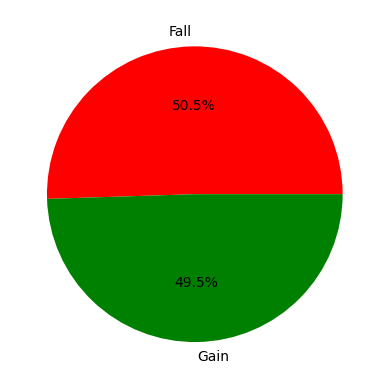

In [ ]:
# Gain And Fall
df['Gain/Fall'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df.tail()

plt.pie(df['Gain/Fall'].value_counts().values,
        labels=["Fall", "Gain"], autopct='%1.1f%%',colors=["red","green"])
plt.show()

X_cls = df.drop(['Close', 'Gain/Fall'], axis=1)
y_cls = df['Gain/Fall']

train_size_cls = int(len(df) * 0.8)
X_train_cls, X_test_cls = X_cls.iloc[:train_size_cls], X_cls.iloc[train_size_cls:]
y_train_cls, y_test_cls = y_cls.iloc[:train_size_cls], y_cls.iloc[train_size_cls:]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

models_class = [LogisticRegression(),
  XGBClassifier(),
  RandomForestClassifier(n_estimators=100, random_state=42),
  DecisionTreeClassifier(random_state=42),
  KNeighborsClassifier(n_neighbors=5),
  GradientBoostingClassifier(n_estimators=100, random_state=42)]

validation_scores = {}

for i in range(6):
  models_class[i].fit(X_train_cls, y_train_cls)

  print(f'{models_class[i].__class__.__name__} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(
    y_train_cls, models_class[i].predict_proba(X_train_cls)[:,1]))
  print('Validation Accuracy : ', metrics.roc_auc_score(
    y_test_cls, models_class[i].predict_proba(X_test_cls)[:,1]))
  print()
  validation_scores[models_class[i].__class__.__name__] = metrics.roc_auc_score(
    y_test_cls, models_class[i].predict_proba(X_test_cls)[:,1])

best_model_class_name = max(validation_scores, key=validation_scores.get)
best_model_class = models_class[[model.__class__.__name__ for model in models_class].index(best_model_class_name)]

print(f"\nSelected Best Model: {best_model_class_name} with validation score: {validation_scores[best_model_class_name]:.4f}")

LogisticRegression : 
Training Accuracy :  0.5080644450500704
Validation Accuracy :  0.4907020844698277

XGBClassifier : 
Training Accuracy :  0.9490835976504289
Validation Accuracy :  0.490965565612371

RandomForestClassifier : 
Training Accuracy :  0.9999999420145311
Validation Accuracy :  0.4875393830088062

DecisionTreeClassifier : 
Training Accuracy :  0.9999999420145311
Validation Accuracy :  0.49455503230427245

KNeighborsClassifier : 
Training Accuracy :  0.7475651321778762
Validation Accuracy :  0.4907067232223373

GradientBoostingClassifier : 
Training Accuracy :  0.7169018363997982
Validation Accuracy :  0.4935196627441375


Selected Best Model: DecisionTreeClassifier with validation score: 0.4946


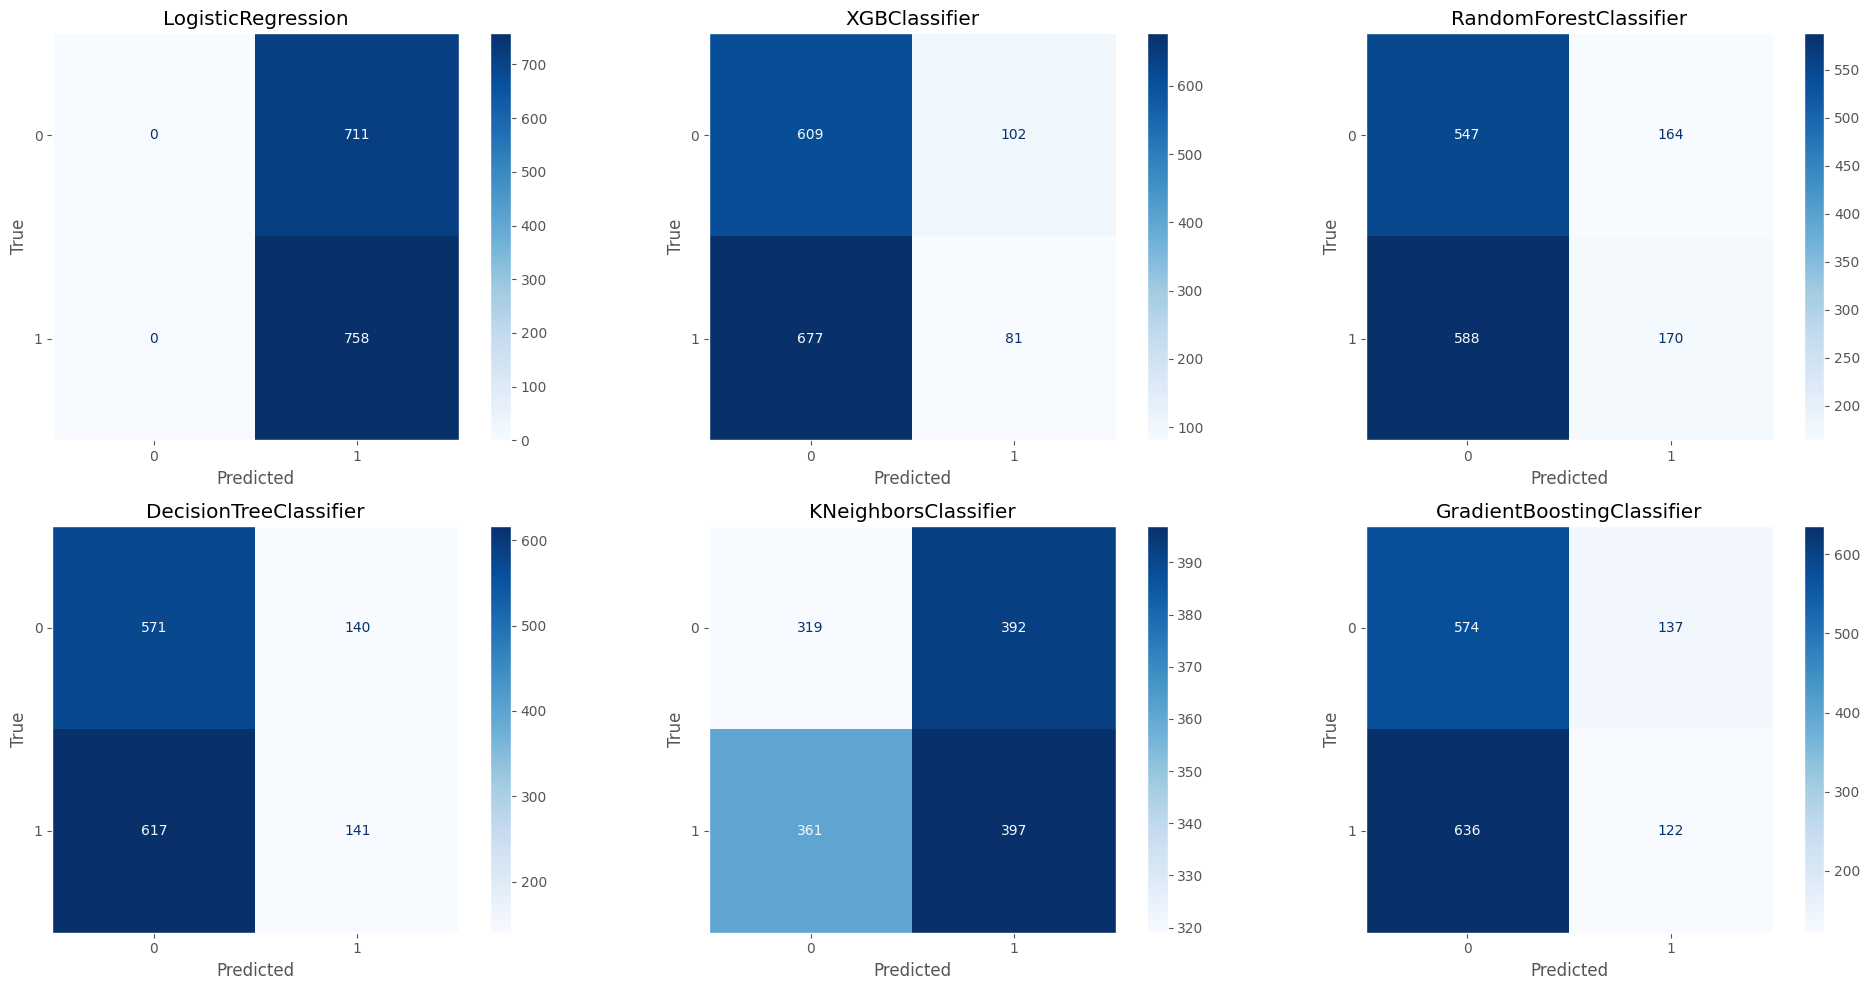

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()  # Flatten the 2D array of axes for easy iteration

for i, model in enumerate(models_class):
    y_pred = model.predict(X_test_cls)

    # Confusion Matrix :
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_cls, y_test_cls, ax=axes[i], cmap='Blues', display_labels=model.classes_)
    axes[i].set_title(f'{model.__class__.__name__}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].grid(False)

plt.tight_layout()
plt.show()


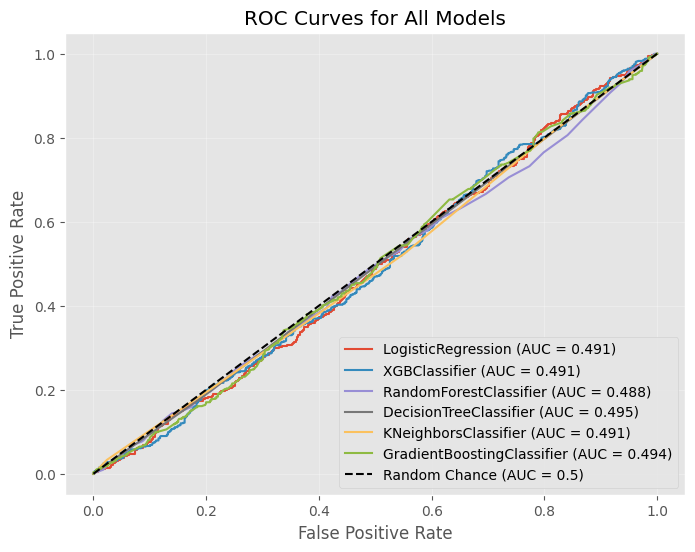

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay # AUC and ROC Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for model in models_class:
    y_probs = model.predict_proba(X_test_cls)[:, 1]

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test_cls, y_probs)
    auc_score = roc_auc_score(y_test_cls, y_probs)

    plt.plot(fpr, tpr, label=f'{model.__class__.__name__} (AUC = {auc_score:.3f})')

# Plot random chance diagonal (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label="Random Chance (AUC = 0.5)")


plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Predict probability of gain (class 1)
prob_gain = best_model_class.predict_proba(today_data_df)[:, 1]

prediction = 1 if prob_gain > 0.5 else 0  #we take threshold 0.5 (can adjust if want)
if prediction == 1:
    print("Gain ")
else:
    print("Fall ")

Fall 


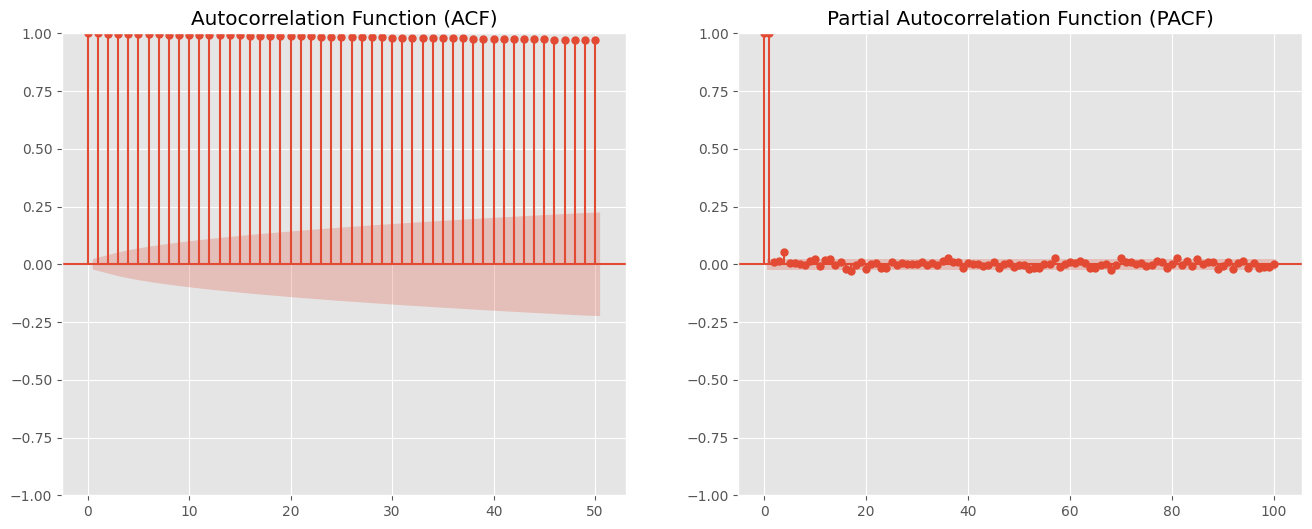

In [ ]:
#ARIMA

import warnings
warnings.filterwarnings('ignore')
!pip install statsmodels --quiet

from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

series = df_raw['Close']
!pip install statsmodels --quiet

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF(AutoCorrelation Function) and PACF (Partial Autocorrelation Function)
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plot_acf(series, lags=50, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

plt.subplot(1,2,2)
plot_pacf(series, lags=100, ax=plt.gca(), method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')

plt.show()

train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

SARIMA RMSE: 167.65


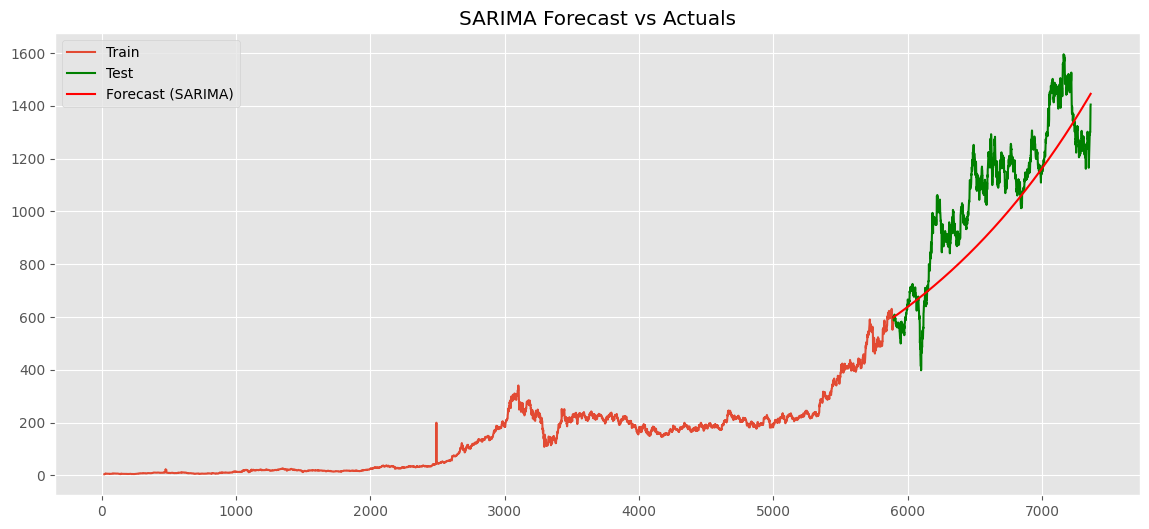

In [ ]:
!pip install statsmodels --quiet

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

series = df_raw['Close']

train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# Set SARIMA orders
order = (1, 0, 1)
seasonal_order = (1, 0, 1, 24) #seasonality is 24 which means 2 years

sarima_model = SARIMAX(train,
                       order=order,
                       seasonal_order=seasonal_order,
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit()

n_periods = len(test)
forecast = sarima_result.forecast(steps=n_periods)

rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'SARIMA RMSE: {rmse:.2f}')

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, color='green', label='Test')
plt.plot(test.index, forecast, color='red', label='Forecast (SARIMA)')
plt.title('SARIMA Forecast vs Actuals')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Predict Today's Close Price using SARIMA
import warnings
warnings.filterwarnings('ignore')

full_sarima_model = SARIMAX(series,
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
full_sarima_result = full_sarima_model.fit()

today_forecast = sarima_result.forecast(steps=1)
predicted_today_close = today_forecast.values[0]

actual_today_close = today_data['Close'].item()

sarima_accuracy = (1 - abs(actual_today_close - predicted_today_close) / actual_today_close) * 100

print("Today's Close Prediction Results with SARIMA")
print(f"Predicted Close Value (SARIMA): {predicted_today_close:.2f}")
print(f"Actual Close Value: {actual_today_close:.2f}")
print(f"Prediction Accuracy: {sarima_accuracy:.2f}%")

Today's Close Prediction Results with SARIMA
Predicted Close Value (SARIMA): 599.35
Actual Close Value: 1405.00
Prediction Accuracy: 42.66%


In [ ]:
def generate_signals(y_true, y_pred, threshold=0.01):
    signals = []
    for actual, pred in zip(y_true, y_pred):
        change = (pred - actual) / actual
        if change > threshold:
            signals.append('Buy')
        elif change < -threshold:
            signals.append('Sell')
        else:
            signals.append('Hold')
    return signals

y_true = y_test.values.flatten()
y_pred = best_model.predict(X_test)
if len(y_pred.shape) > 1:
    y_pred = y_pred.flatten()

min_length = min(len(y_true), len(y_pred))
y_true = y_true[:min_length]
y_pred = y_pred[:min_length]

# Generate signals
signals = generate_signals(y_true, y_pred)

df_signals = pd.DataFrame({
    'Actual_Close': y_true,
    'Predicted_Close': y_pred,
    'Signal': signals
})
df_signals.index = y_test.index[:min_length]

def backtest_strategy(df, initial_cash=1000):
    cash = initial_cash
    shares = 0
    portfolio_values = []

    for idx, row in df.iterrows():
        signal = row['Signal']
        price = row['Actual_Close']

        if signal == 'Buy' and cash > 0:
            shares = cash / price
            cash = 0

        elif signal == 'Sell' and shares > 0:
            cash = shares * price
            shares = 0

        portfolio_value = cash + shares * price
        portfolio_values.append(portfolio_value)

    return portfolio_values

portfolio_values = backtest_strategy(df_signals)
df_signals['Portfolio_Value'] = portfolio_values

final_value = portfolio_values[-1]
total_return = (final_value - 1000) / 1000 * 100
print(f"\nFinal Portfolio Value: ₹{final_value:.2f}")
print(f" Total Strategy Return: {total_return:.2f}%")

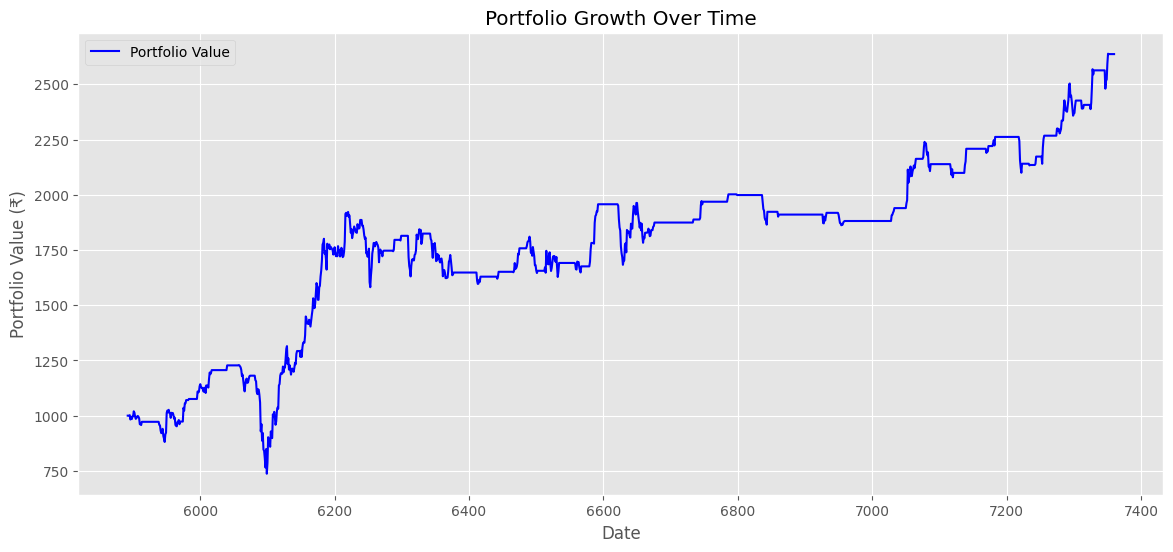

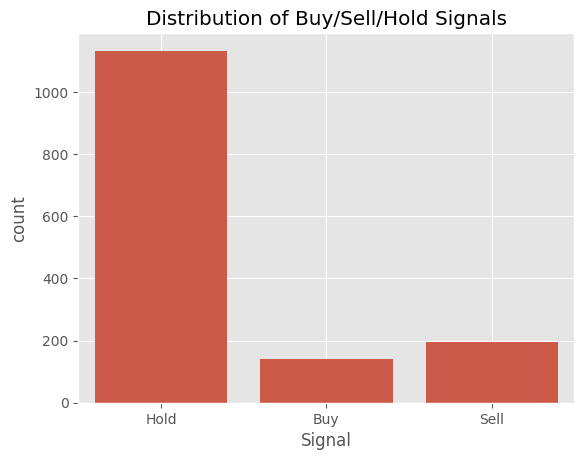

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df_signals.index, df_signals['Portfolio_Value'], label='Portfolio Value', color='blue')
plt.title('Portfolio Growth Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.grid(True)
plt.show()

import seaborn as sns

sns.countplot(x='Signal', data=df_signals)
plt.title('Distribution of Buy/Sell/Hold Signals')
plt.grid(True)
plt.show()

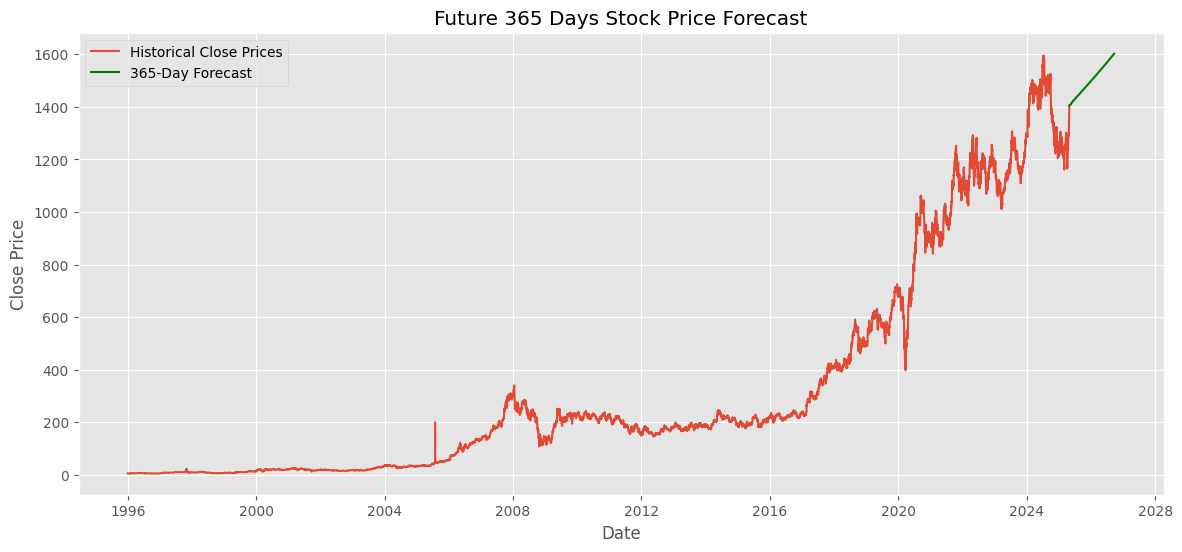


365-Day Future Stock Price Forecast:
            Predicted_Close
Date                       
2025-05-01      1405.756917
2025-05-02      1405.991049
2025-05-05      1406.278099
2025-05-06      1406.877208
2025-05-07      1407.331280

             Predicted_Close
Date                       
2026-09-17      1600.007595
2026-09-18      1600.576331
2026-09-21      1601.145269
2026-09-22      1601.714410
2026-09-23      1602.283752


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

last_date = pd.to_datetime(df_copy['Date'].iloc[-1])  # Last available real date

# Now Forecast next 30 business days (using SARIMA)
future_forecast = full_sarima_result.forecast(steps=365)

future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=365, freq='B')

future_forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close': future_forecast.values
})
future_forecast_df.set_index('Date', inplace=True)

plt.figure(figsize=(14,6))
plt.plot(df_copy['Date'], df_copy['Close'], label='Historical Close Prices')

plt.plot(future_forecast_df.index, future_forecast_df['Predicted_Close'], label='365-Day Forecast', color='green')

plt.title('Future 365 Days Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

print("\n365-Day Future Stock Price Forecast:")
print(future_forecast_df.head())
print("\n",future_forecast_df.tail())